In [1]:
# ============================================================
# LINEAR ML MODELS — Google Colab Ready
# ============================================================
# Run each section independently or all at once.
# Install: pip install numpy matplotlib scikit-learn
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

Intercept (β₀):  6.7112
Coefficient (β₁): 3.3997
R² Score:         0.9639
MSE:              16.3425


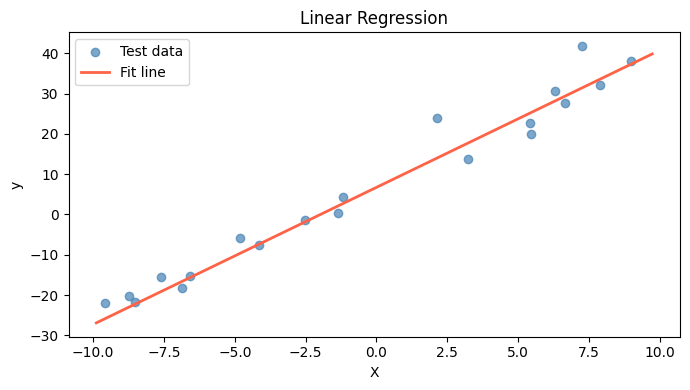

In [3]:
# ============================================================
# 1. LINEAR REGRESSION
# ============================================================

# Generate data for Linear Regression
X_lr = np.random.uniform(-10, 10, (100, 1))
y_lr = 3.5 * X_lr.squeeze() + 7 + np.random.normal(0, 5, 100)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

# Fit
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"Intercept (β₀):  {lr.intercept_:.4f}")
print(f"Coefficient (β₁): {lr.coef_[0]:.4f}")
print(f"R² Score:         {r2_score(y_test, y_pred):.4f}")
print(f"MSE:              {mean_squared_error(y_test, y_pred):.4f}")

# Plot
plt.figure(figsize=(7, 4))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.7, label='Test data')
x_line = np.linspace(X_lr.min(), X_lr.max(), 200).reshape(-1, 1)
plt.plot(x_line, lr.predict(x_line), color='tomato', linewidth=2, label='Fit line')
plt.title("Linear Regression")
plt.xlabel("X"); plt.ylabel("y")
plt.legend(); plt.tight_layout(); plt.show()


4. LOGISTIC REGRESSION
Intercept (β₀):   0.0119
Coefficients:      [0.48130537 3.72622303]
Accuracy:          0.9500


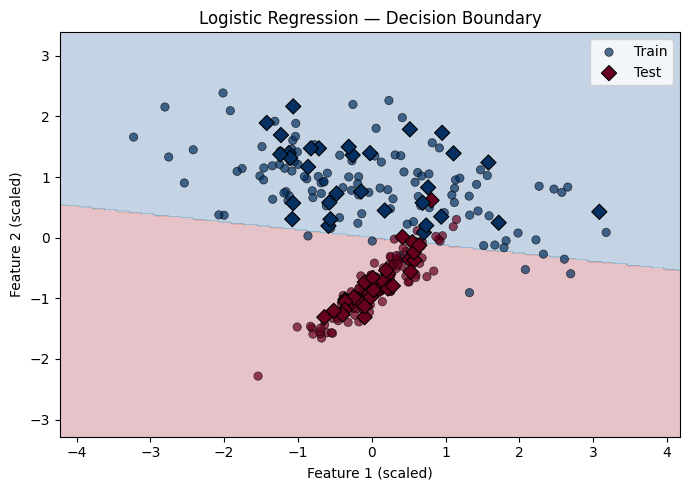

In [4]:

# ============================================================
# 4. LOGISTIC REGRESSION
# ============================================================

print("\n" + "=" * 50)
print("4. LOGISTIC REGRESSION")
print("=" * 50)

# Binary classification data
from sklearn.datasets import make_classification

X_log, y_log = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, random_state=42, n_clusters_per_class=1
)

X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_sc, y_train)
y_pred_log = log_reg.predict(X_test_sc)

print(f"Intercept (β₀):   {log_reg.intercept_[0]:.4f}")
print(f"Coefficients:      {log_reg.coef_[0]}")
print(f"Accuracy:          {accuracy_score(y_test, y_pred_log):.4f}")

# Plot: decision boundary
plt.figure(figsize=(7, 5))
x_min, x_max = X_train_sc[:, 0].min() - 1, X_train_sc[:, 0].max() + 1
y_min, y_max = X_train_sc[:, 1].min() - 1, X_train_sc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
plt.scatter(X_train_sc[:, 0], X_train_sc[:, 1], c=y_train,
            cmap='RdBu', edgecolors='k', linewidths=0.5, alpha=0.7, label='Train')
plt.scatter(X_test_sc[:, 0], X_test_sc[:, 1], c=y_test,
            cmap='RdBu', marker='D', edgecolors='k', linewidths=0.8, s=60, label='Test')
plt.title("Logistic Regression — Decision Boundary")
plt.xlabel("Feature 1 (scaled)"); plt.ylabel("Feature 2 (scaled)")
plt.legend(); plt.tight_layout(); plt.show()